# ML Test - Fabio Rodrigues

In [634]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Clustering libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# API libraries
import joblib
from fastapi import FastAPI

## Importing the dataset

In [473]:
data_path = Path("research_centers.csv")

In [475]:
df = pd.read_csv(data_path)
df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


### Inspect the data

In [478]:
# Overview of the dataset
df.describe()

,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,50.542770,-1.554638,5.660000,1.860000,2.240000,0.568843,0.321164
std,0.320289,0.253853,3.146816,1.340271,1.684988,0.249511,0.182562
min,50.007100,-1.976900,1.000000,0.000000,0.000000,0.119515,0.056541
25%,50.240375,-1.747225,3.000000,1.000000,1.000000,0.344145,0.173814
50%,50.635350,-1.561000,5.000000,2.000000,2.000000,0.585503,0.297584
75%,50.831475,-1.374175,8.750000,3.000000,3.000000,0.800489,0.476387
max,50.994600,-1.049300,11.000000,4.000000,5.000000,0.992984,0.697016


In [480]:
# Checking for missing values
df.isnull().sum()

researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64

## EDA

### Bar chart plotter

In [657]:
def plot_bar(x, y, title, ylabel):
    plt.bar(x, y, edgecolor="k", color="dodgerblue")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("")
    plt.show()

### Number of cities

In [484]:
## Number of cities
number_of_cities = np.sort(df["city"].unique())
print(f"List of cities: {number_of_cities}")
print(f"Number of cities: {number_of_cities.size}")


List of cities: ['City 1' 'City 2' 'City 3' 'City 4' 'City 5']
Number of cities: 5


### Number of research centres/city

In [487]:
## Number of research centres/city
df_res_centre = df.groupby(["city"]).size()
df_res_centre

city
City 1    11
City 2     6
City 3    14
City 4    10
City 5     9
dtype: int64

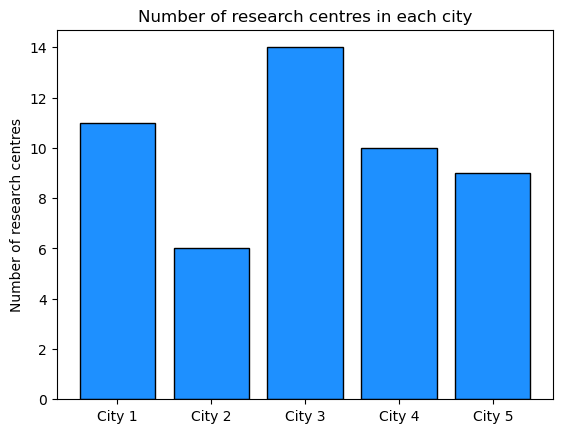

In [611]:
plot_bar(number_of_cities,
         df_res_centre,
         "Number of research centres in each city",
         "Number of research centres")

### Internal facilites histogram

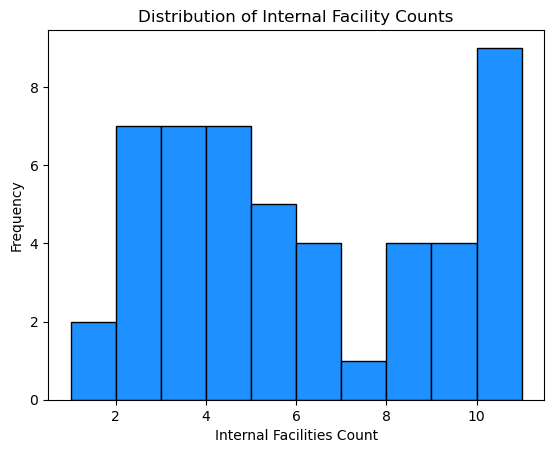

In [492]:
plt.hist(df["internalFacilitiesCount"], 
         edgecolor="k",
         color="dodgerblue")
plt.xlabel("Internal Facilities Count")
plt.ylabel("Frequency")
plt.title("Distribution of Internal Facility Counts")
plt.show()

### Number of facilities/research centre

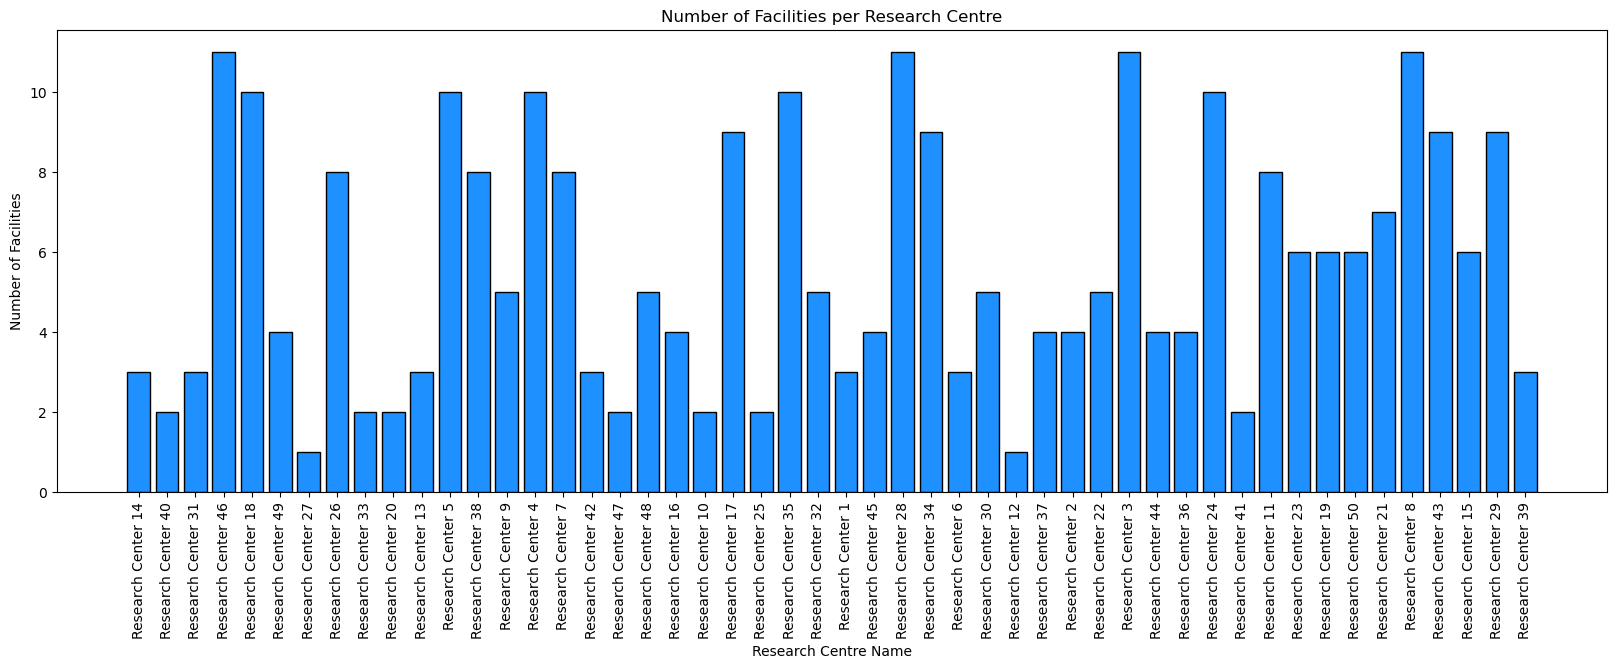

In [495]:
## Number of facilities/research centre

plt.figure(figsize=(20, 6))
plt.bar(df["researchCenterName"], 
        df["internalFacilitiesCount"],
        edgecolor="k",
        color="dodgerblue")
plt.xlabel("Research Centre Name")
plt.ylabel("Number of Facilities")
plt.title("Number of Facilities per Research Centre")
plt.xticks(rotation=90)
plt.show()


### Number of facilities/city

In [498]:
## Number of facilities/city
facilities_per_city = (
    df.groupby("city")["internalFacilitiesCount"].sum().reset_index())
facilities_per_city

,city,internalFacilitiesCount
0,City 1,72
1,City 2,32
2,City 3,71
3,City 4,54
4,City 5,54


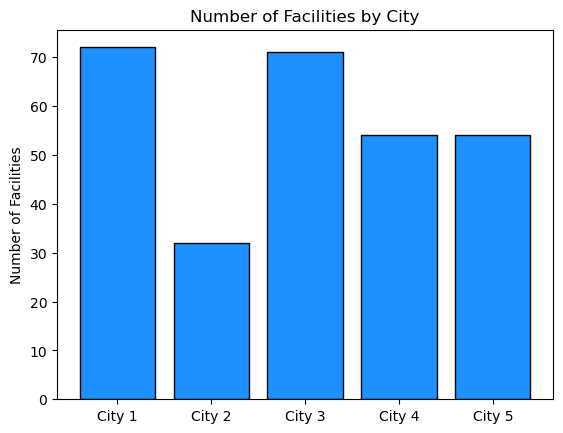

In [615]:
plot_bar(facilities_per_city["city"],
         facilities_per_city["internalFacilitiesCount"],
         "Number of Facilities by City",
         "Number of Facilities")

### Facility diversity/city

In [640]:
## Facility diversity/city
fac_diversity_per_city = (
    df.groupby("city")["facilityDiversity_10km"].mean().reset_index())
fac_diversity_per_city

,city,facilityDiversity_10km
0,City 1,0.647373
1,City 2,0.582203
2,City 3,0.501827
3,City 4,0.542367
4,City 5,0.597617


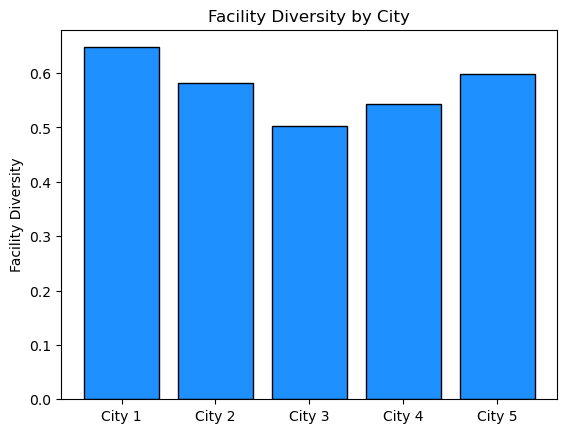

In [644]:
plot_bar(fac_diversity_per_city["city"],
         fac_diversity_per_city["facilityDiversity_10km"],
         "Facility Diversity by City",
         "Facility Diversity")


### Facility density/city

In [646]:
## Facility density/city
fac_density_per_city = (
    df.groupby("city")["facilityDensity_10km"].mean().reset_index())
fac_density_per_city

,city,facilityDensity_10km
0,City 1,0.372853
1,City 2,0.322183
2,City 3,0.300492
3,City 4,0.289341
4,City 5,0.324823


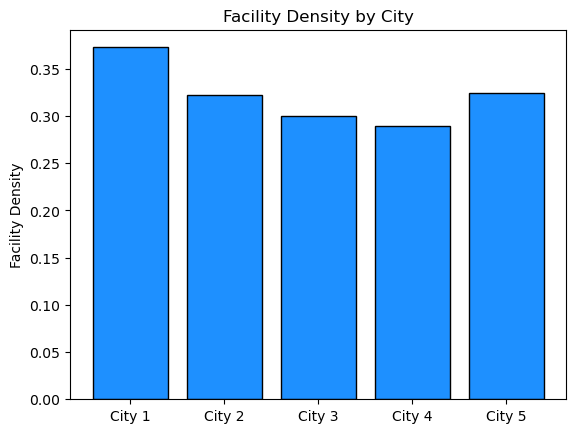

In [648]:
plot_bar(fac_density_per_city["city"],
         fac_density_per_city["facilityDensity_10km"],
         "Facility Density by City",
         "Facility Density")

### Number of hospitals per city

In [513]:
## Number of hospitals per city
hospitals_per_city = (
    df.groupby("city")["hospitals_10km"].sum().reset_index())
hospitals_per_city

,city,hospitals_10km
0,City 1,22
1,City 2,12
2,City 3,22
3,City 4,20
4,City 5,17


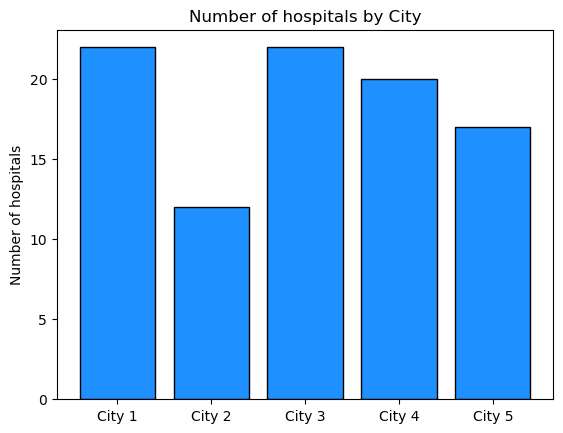

In [627]:
plot_bar(hospitals_per_city["city"],
        hospitals_per_city["hospitals_10km"],
        "Number of hospitals by City",
        "Number of hospitals")

### Number of pharmacies per city

In [518]:
## Number of pharmacies per city
pharmacies_per_city = (
    df.groupby("city")["pharmacies_10km"].sum().reset_index())
pharmacies_per_city

,city,pharmacies_10km
0,City 1,34
1,City 2,16
2,City 3,27
3,City 4,16
4,City 5,19


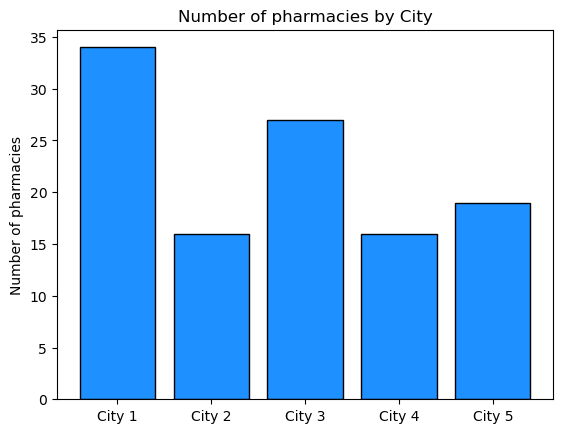

In [631]:
plot_bar(pharmacies_per_city["city"],
         pharmacies_per_city["pharmacies_10km"],
         "Number of pharmacies by City",
         "Number of pharmacies")

### Hospital access

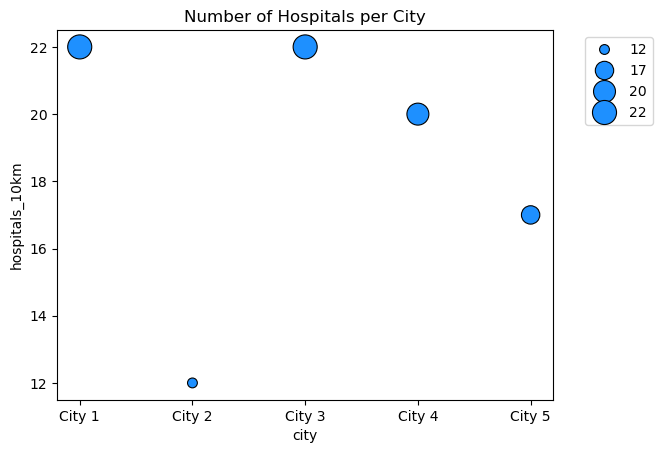

In [523]:
sns.scatterplot(
    data=hospitals_per_city,
    x="city",
    y="hospitals_10km",
    size="hospitals_10km",
    sizes=(50,300),
    edgecolor="k",
    color="dodgerblue")
plt.title("Number of Hospitals per City")
plt.legend(bbox_to_anchor=(1.05, 1), 
           loc=2)
plt.show()

### Pharmacy access

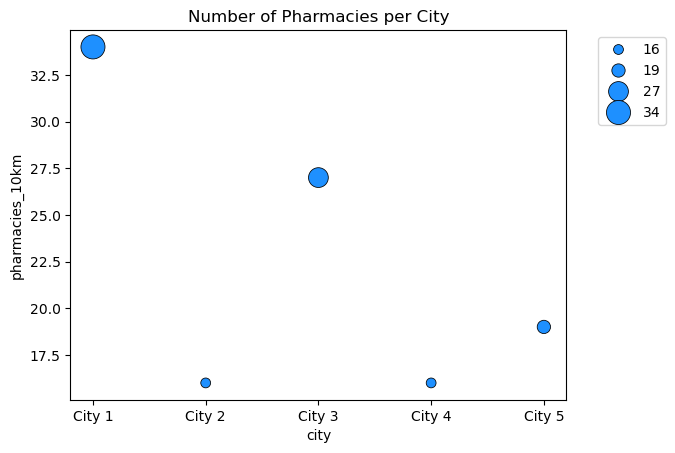

In [526]:
sns.scatterplot(
    data=pharmacies_per_city,
    x="city",
    y="pharmacies_10km",
    size="pharmacies_10km",
    sizes=(50,300),
    edgecolor="k",
    color="dodgerblue")
plt.title("Number of Pharmacies per City")
plt.legend(bbox_to_anchor=(1.05, 1), 
           loc=2)
plt.show()

## Features Selection

### Correlation between features

In [530]:
# Correlation between features
cols = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDensity_10km",
    "facilityDiversity_10km"]

correlation = df[cols].corr()
correlation

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDensity_10km,facilityDiversity_10km
internalFacilitiesCount,1.000000,0.878828,0.889402,0.900576,0.903568
hospitals_10km,0.878828,1.000000,0.801383,0.868519,0.852964
pharmacies_10km,0.889402,0.801383,1.000000,0.832407,0.834209
facilityDensity_10km,0.900576,0.868519,0.832407,1.000000,0.868877
facilityDiversity_10km,0.903568,0.852964,0.834209,0.868877,1.000000


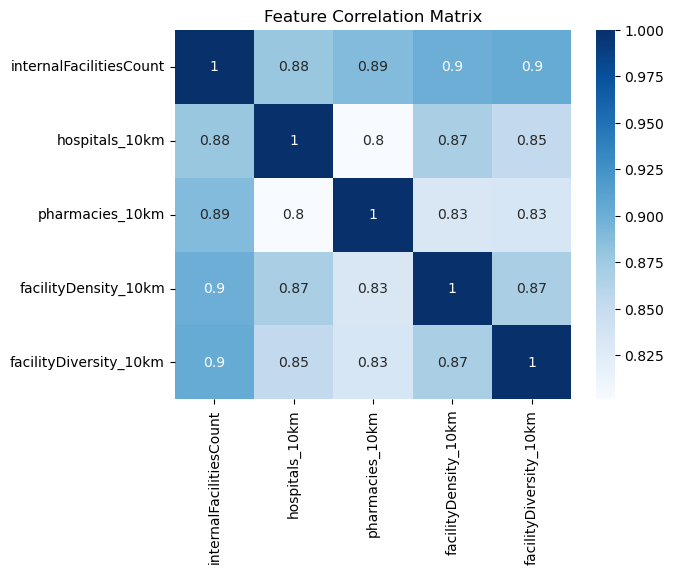

In [532]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues")

plt.title("Feature Correlation Matrix")
plt.show()

### Discussion

**Question 1:"Why were these features selected?"**

*The original dataset contained a combination of numeric and non-numeric data. By investigating the numeric data (since non-numeric data consisted essentially of ID information), it was clear that `longitude` and `latitude` would describe geographic location, but they  don't offer information regarding research centre quality, and thus were not considered in further analysis.*

*For this reason, the selected features from the dataset were  `internalFacilitiesCount`,`hospitals_10km`,    `pharmacies_10km`,`facilityDiversity_10km`,`facilityDensity_10km`.*

---
**Question 2: "Which features have the highest correlation with overall facility diversity or quality?"**

*By performing the EDA and correlation analysis, the features that had the highest correlation with facility diversity were `internalFacilitiesCount (0.90)`,`facilityDensity_10km (0.87)`, and `hospitals_10km (0.85)`.*

*This suggests that research centres with higher capacity are in areas with denser and more diverse infrastructure, combined with healthcare availability.*

### Normalisation
This ensures that variables that are on different scales are comparable.

In [537]:
features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km"]

X = df[features]
X

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,3,1,0,0.374488,0.177506
1,2,1,1,0.391903,0.108965
2,3,0,1,0.293552,0.076155
3,11,4,4,0.884502,0.697016
4,10,4,5,0.842611,0.568983
5,4,2,1,0.458282,0.214188
6,1,0,1,0.143468,0.123418
7,8,3,3,0.992984,0.523311
8,2,0,0,0.297995,0.172583
9,2,1,1,0.287306,0.094345


In [539]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [541]:
# Visualising the scaled data as a dataframe
X_scaled = pd.DataFrame(X_scaled, columns=features)
X_scaled

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,-0.853881,-0.648176,-1.342883,-0.786850,-0.794887
1,-1.174889,-0.648176,-0.743382,-0.716344,-1.174139
2,-0.853881,-1.401868,-0.743382,-1.114522,-1.355681
3,1.714182,1.612902,1.055123,1.277957,2.079667
4,1.393174,1.612902,1.654624,1.108360,1.371232
5,-0.532873,0.105517,-0.743382,-0.447607,-0.591916
6,-1.495897,-1.401868,-0.743382,-1.722139,-1.094166
7,0.751158,0.859210,0.455621,1.717151,1.118522
8,-1.174889,-1.401868,-1.342883,-1.096533,-0.822124
9,-1.174889,-0.648176,-0.743382,-1.139808,-1.255032


## Clustering model

### K-Means

#### Calculating the K-Means


In [548]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

In [550]:
kmeans

KMeans(n_clusters=3, n_init=10, random_state=42)

In [552]:
labels

array([2, 2, 2, 1, 1, 0, 2, 1, 2, 2, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 2, 1,
       2, 1, 0, 2, 0, 1, 1, 2, 0, 2, 0, 0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 2], dtype=int32)

#### Visualising clusters as a dataframe

In [555]:
# Visualising clusters as a dataframe
df["cluster"] = labels

summary = df.groupby("cluster")[features].mean()
summary

,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
cluster,,,,,
0,4.941176,1.529412,2.058824,0.559935,0.289845
1,9.529412,3.470588,4.117647,0.850424,0.536852
2,2.312500,0.500000,0.437500,0.279126,0.125271


In [557]:
df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1


#### Assigning a tier to each cluster

In [560]:
# Assigning a tier to each cluster
cluster_to_tier = {
    1: "Premium",
    0: "Standard",
    2: "Basic"}

#### Adding clustering info to the dataframe

In [563]:
# Adding clustering info to the dataframe
df["qualityTier"] = df["cluster"].map(cluster_to_tier)
df.head()

,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km,cluster,qualityTier
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506,2,Basic
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965,2,Basic
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155,2,Basic
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016,1,Premium
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983,1,Premium


#### Saving the model

In [566]:
# Create a pipeline to save the model
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=3, random_state=42, n_init=10))])

pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

In [568]:
# Saving the file using joblib
joblib.dump(pipeline, "clustering_pipeline.joblib")

['clustering_pipeline.joblib']

### Silhouette Score


In [650]:
score = silhouette_score(X_scaled, labels)
print(f"Silhouette score: {score:.3f}")

Silhouette score: 0.552


The Silhouette score indicates reasonably good separation between the 3 clusters.
Clustering is appropriate for this dataset, since it relies on natural groupings based on city infrastructure, thus allowing them to be categorised as Basic, Standard and Premium.

This model could be further improved by incorporating more meaningful features, such as research output, number of research staff, and number of publications.

## Model interpretation

### Which cluster has the highest internal facility counts and external healthcare access?

*From `# Visualising clusters as a dataframe`, we have features' averages:*

| cluster | internalFacilitiesCount | hospitals_10km | pharmacies_10km | facilityDiversity_10km | facilityDensity_10km |
|---------|------------------------|----------------|-----------------|------------------------|----------------------|
| 0 | 4.941176 | 1.529412 | 2.058824 | 0.559935 | 0.289845 |
| 1 | 9.529412 | 3.470588 | 4.117647 | 0.850424 | 0.536852 |
| 2 | 2.312500 | 0.500000 | 0.437500 | 0.279126 | 0.125271 |

*`Cluster 1` has the **highest averages** for all features, while `Cluster 2` has the **lowest**. `Cluster 0` is **intermediary**.*

---

### Are high-quality centers concentrated in specific cities?

*Now, if we investigate if there is a concentration of high-quality centres in specific cities, we can verify the following:*

In [579]:
city_tier_counts = df.groupby(
    ["city", "qualityTier"]).size().unstack(fill_value=0)
city_tier_counts

qualityTier,Basic,Premium,Standard
city,,,
City 1,1,4,6
City 2,2,2,2
City 3,5,4,5
City 4,5,4,1
City 5,3,3,3


*Observing the table above, we can see that all cities have similar numbers of Premium centres. Some cities have more research centres than others (City 1 has only 1 Basic centre, compared to City 3 and City 4, that have 5). But focusing solely in the Premium centres, the number is very similar in all cities.*

*In terms of density, we can observe:*

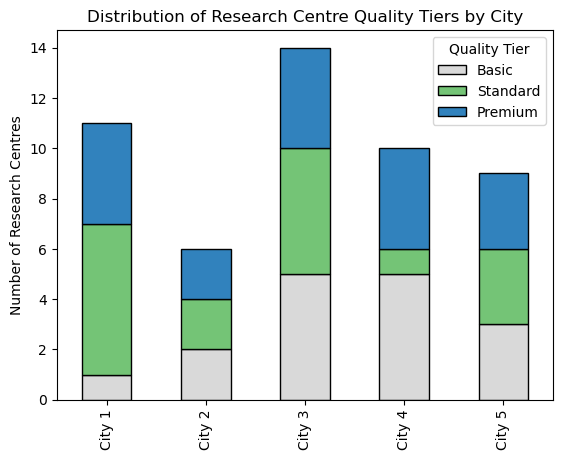

In [586]:
city_tier_counts = city_tier_counts[["Basic", "Standard", "Premium"]]
city_tier_counts.plot(kind="bar", 
                      stacked=True,
                      cmap="tab20c_r",
                      edgecolor="k")

plt.title("Distribution of Research Centre Quality Tiers by City")
plt.xlabel("")
plt.ylabel("Number of Research Centres")
plt.legend(title="Quality Tier")


plt.show()

*This shows that **Premium centres appear in similar number in all cities**, but **City 3 has the largest number** of centres, while **City 2 has the lowest**.*

### Does diversity or density play a stronger role?

*If we revisit `# Visualising clusters as a dataframe` averages, we see:*

| cluster | internalFacilitiesCount | hospitals_10km | pharmacies_10km | facilityDiversity_10km | facilityDensity_10km |
|---------|------------------------|----------------|-----------------|------------------------|----------------------|
| 0 | 4.941176 | 1.529412 | 2.058824 | 0.559935 | 0.289845 |
| 1 | 9.529412 | 3.470588 | 4.117647 | 0.850424 | 0.536852 |
| 2 | 2.312500 | 0.500000 | 0.437500 | 0.279126 | 0.125271 |

*And if we visualise it in a line plot:*

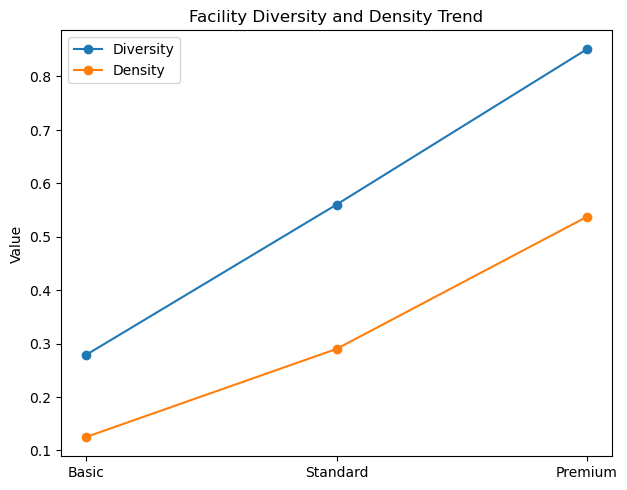

In [591]:
x = [0, 1, 2]
clusters = [2, 0, 1]

plt.plot(x,
         summary.loc[clusters, "facilityDiversity_10km"],
         marker="o",
         label="Diversity")

plt.plot(x,
         summary.loc[clusters, "facilityDensity_10km"],
         marker="o",
         label="Density")

plt.legend()
plt.xticks(x, ["Basic", "Standard", "Premium"])
plt.ylabel("Value")
plt.tight_layout()
plt.title("Facility Diversity and Density Trend")
plt.show()

*We can observe that `facilityDiversity_10km` shows a larger separation between the clusters, with increasing values as we move from **Basic** $\rightarrow$ **Standard** $\rightarrow$ **Premium**, although `facilityDensity_10km` also displays a similar trend, indicating it also contributes to the clustering.*

## API Deployment (FastAPI)

This model could be commercialised as a platform for infrastructure development in a R&D context. This could help the identification of optimal locations, or to identify gaps in the infrastructure, thus guiding future improvements.

In [596]:
from fastapi import FastAPI
import pandas as pd
import joblib

app = FastAPI()

model = joblib.load("clustering_pipeline.joblib")

cluster_to_category = {
    1: "Premium",
    0: "Standard",
    2: "Basic"}

@app.post("/predict")
def predict(data: dict):
    X_new = pd.DataFrame([data])
    cluster = int(model.predict(X_new)[0])
    category = cluster_to_category[cluster]
    return {"predictedCategory": category}